In [ ]:
pip install pandas numpy scikit-learn tensorflow matplotlib

In [45]:
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

df.columns = df.columns.str.strip().str.replace(" ", "_")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.dropna()
df.drop('customerID', axis=1, inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [46]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

Optimizer: Adam
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])


history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
176/176 [==============================] - 1s 2ms/step - loss: 0.5330 - accuracy: 0.7111 - val_loss: 0.4589 - val_accuracy: 0.7669
Epoch 2/20
176/176 [==============================] - 0s 1ms/step - loss: 0.4332 - accuracy: 0.7909 - val_loss: 0.4472 - val_accuracy: 0.7697
Epoch 3/20
176/176 [==============================] - 0s 2ms/step - loss: 0.4215 - accuracy: 0.7952 - val_loss: 0.4426 - val_accuracy: 0.7832
Epoch 4/20
176/176 [==============================] - 0s 1ms/step - loss: 0.4150 - accuracy: 0.8028 - val_loss: 0.4400 - val_accuracy: 0.7811
Epoch 5/20
176/176 [==============================] - 0s 1ms/step - loss: 0.4098 - accuracy: 0.8046 - val_loss: 0.4414 - val_accuracy: 0.7882
Epoch 6/20
176/176 [==============================] - 0s 1ms/step - loss: 0.4070 - accuracy: 0.8064 - val_loss: 0.4406 - val_accuracy: 0.7868
Epoch 7/20
176/176 [==============================] - 0s 1ms/step - loss: 0.4035 - accuracy: 0.8080 - val_loss: 0.4401 - val_accuracy: 0.7882
Epoch 

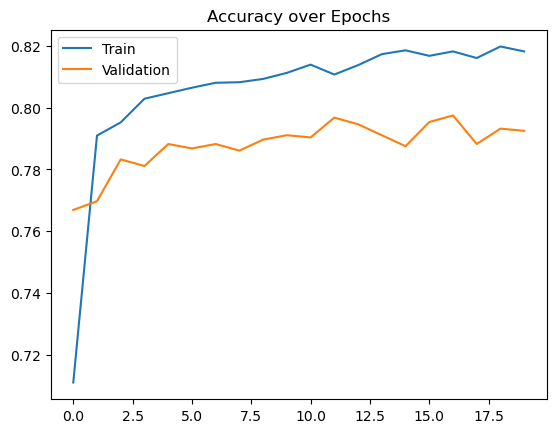

In [47]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy over Epochs')
plt.legend()
plt.show()

In [48]:
# Customer with churn probability NO
new_customer = pd.DataFrame([{
    'gender': 0, 'SeniorCitizen': 0, 'Partner': 1, 'Dependents': 0,
    'tenure': 12, 'PhoneService': 1, 'MultipleLines': 0, 'InternetService': 0,
    'OnlineSecurity': 2, 'OnlineBackup': 0, 'DeviceProtection': 1,
    'TechSupport': 0, 'StreamingTV': 0, 'StreamingMovies': 1, 'Contract': 0,
    'PaperlessBilling': 1, 'PaymentMethod': 0, 'MonthlyCharges': 50.0, 'TotalCharges': 100.0
}])

new_customer_scaled = scaler.transform(new_customer)
churn_prob = model.predict(new_customer_scaled)[0][0]
churn_label = int(churn_prob > 0.5)

print(f"Churn Probability: {churn_prob:.2f}")
print(f"Churn Prediction: {churn_label} ({'Yes' if churn_label==1 else 'No'})")

1/1 [==============================] - 0s 35ms/step
Churn Probability: 0.27
Churn Prediction: 0 (No)


In [49]:
# Customer with churn probability YES
new_customer = pd.DataFrame([{
    'gender': 1, 'SeniorCitizen': 0, 'Partner': 1, 'Dependents': 0,
    'tenure': 1, 'PhoneService': 1, 'MultipleLines': 0, 'InternetService': 1,
    'OnlineSecurity': 0, 'OnlineBackup': 0, 'DeviceProtection': 0,
    'TechSupport': 0, 'StreamingTV': 0, 'StreamingMovies': 1, 'Contract': 0,
    'PaperlessBilling': 1, 'PaymentMethod': 1, 'MonthlyCharges': 50.0, 'TotalCharges': 100.0
}])

new_customer_scaled = scaler.transform(new_customer)
churn_prob = model.predict(new_customer_scaled)[0][0]
churn_label = int(churn_prob > 0.5)

print(f"Churn Probability: {churn_prob:.2f}")
print(f"Churn Prediction: {churn_label} ({'Yes' if churn_label==1 else 'No'})")

1/1 [==============================] - 0s 12ms/step
Churn Probability: 0.58
Churn Prediction: 1 (Yes)
